# EDA — Feature Relationships & Modeling Implications


## Section 0: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

%matplotlib inline

print('All imports successful!')

All imports successful!


In [3]:
df = pd.read_parquet('data/flights_2018_2024_v2.parquet')

print(f'Shape: {df.shape}')
df.head()

Shape: (45968068, 17)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,Dest,CRSDepTime,DepTimeBlk,CRSArrTime,ArrDel15,CRSElapsedTime,Distance,DistanceGroup
0,2018,1,1,1,1,2018-01-01,WN,1491.0,ABQ,BWI,730,0700-0759,1310,0.0,220.0,1670.0,7
1,2018,1,1,1,1,2018-01-01,UA,2102.0,IAH,LAS,1420,1400-1459,1547,0.0,207.0,1222.0,5
2,2018,1,1,1,1,2018-01-01,UA,2101.0,IAH,SFO,2113,2100-2159,2340,0.0,267.0,1635.0,7
3,2018,1,1,1,1,2018-01-01,UA,2100.0,IAH,FLL,2010,2000-2059,2337,0.0,147.0,966.0,4
4,2018,1,1,1,1,2018-01-01,UA,2099.0,SAN,IAH,1340,1300-1359,1848,0.0,188.0,1303.0,6


In [4]:
# Convert dtypes for memory efficiency and correct analysis
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

cat_cols = ['Reporting_Airline', 'Origin', 'Dest', 'DepTimeBlk']
df[cat_cols] = df[cat_cols].astype('category')

df['ArrDel15'] = df['ArrDel15'].astype('Int64')

print('Dtypes after conversion:')
print(df.dtypes)
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Dtypes after conversion:
Year                                        int64
Quarter                                     int64
Month                                       int64
DayofMonth                                  int64
DayOfWeek                                   int64
FlightDate                         datetime64[ns]
Reporting_Airline                        category
Flight_Number_Reporting_Airline           float64
Origin                                   category
Dest                                     category
CRSDepTime                                  int64
DepTimeBlk                               category
CRSArrTime                                  int64
ArrDel15                                    Int64
CRSElapsedTime                            float64
Distance                                  float64
DistanceGroup                               int64
dtype: object

Memory usage: 5.10 GB


## Section 1: Categorical Feature Analysis

In [5]:
# Show categorical columns and their unique value counts
cat_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_values': df.nunique()
})
cat_summary = cat_summary[cat_summary['dtype'] == 'category']
cat_summary = cat_summary.sort_values('unique_values', ascending=False)

print('Categorical columns in the dataset:')
print(cat_summary)

Categorical columns in the dataset:
                      dtype  unique_values
Origin             category            384
Dest               category            384
Reporting_Airline  category             19
DepTimeBlk         category             19


In [6]:
print('Unique values in DepTimeBlk:')
print(sorted(df['DepTimeBlk'].unique()))

Unique values in DepTimeBlk:
['0001-0559', '0600-0659', '0700-0759', '0800-0859', '0900-0959', '1000-1059', '1100-1159', '1200-1259', '1300-1359', '1400-1459', '1500-1559', '1600-1659', '1700-1759', '1800-1859', '1900-1959', '2000-2059', '2100-2159', '2200-2259', '2300-2359']


### 1.1 Delay Rate by Airline

/var/folders/s0/7__mncx10v9f5d7lh_jsd3d00000gn/T/ipykernel_7384/3723812137.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Reporting_Airline')['ArrDel15']


   Reporting_Airline  Pct_Delayed
0                 9E        14.05
4                 DL         14.5
13                QX         14.6
8                 HA        15.16
18                YX        15.65
12                OO        16.75
9                 MQ        18.35
2                 AS        18.43
11                OH        18.47
14                UA        19.07
17                YV        19.32
16                WN        19.45
15                VX        20.05
1                 AA        20.93
5                 EV        21.42
10                NK        21.98
7                 G4        24.68
3                 B6        26.85
6                 F9        26.91


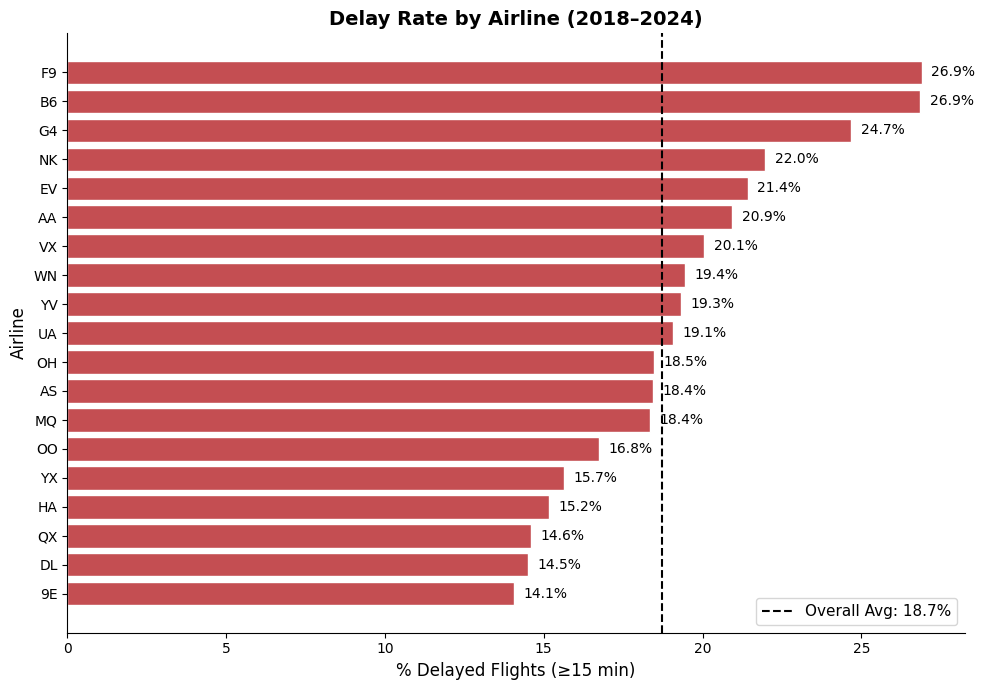

In [7]:
airline_delay = (
    df.groupby('Reporting_Airline')['ArrDel15']
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
      .rename(columns={'ArrDel15': 'Pct_Delayed'})
      .sort_values('Pct_Delayed', ascending=True)
)

print(airline_delay)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    airline_delay['Reporting_Airline'],
    airline_delay['Pct_Delayed'],
    color='#c44e52',
    edgecolor='white'
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

# Overall average line
overall_avg = df['ArrDel15'].mean() * 100
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Airline (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylabel('Airline', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Delay Rate by Origin Airport (Top 20 by Volume)

   Origin  Pct_Delayed
19    SLC        14.74
14    MSP        15.68
6     DTW        15.85
0     ATL        16.30
11    LAX        16.87
17    SEA        17.45
16    PHX        17.80
18    SFO        18.82
3     DCA        18.85
8     IAH        19.17
12    LGA        19.91
1     BOS        20.16
2     CLT        20.36
9     JFK        20.88
10    LAS        21.24
15    ORD        21.78
4     DEN        22.00
5     DFW        22.54
13    MCO        23.17
7     EWR        23.53


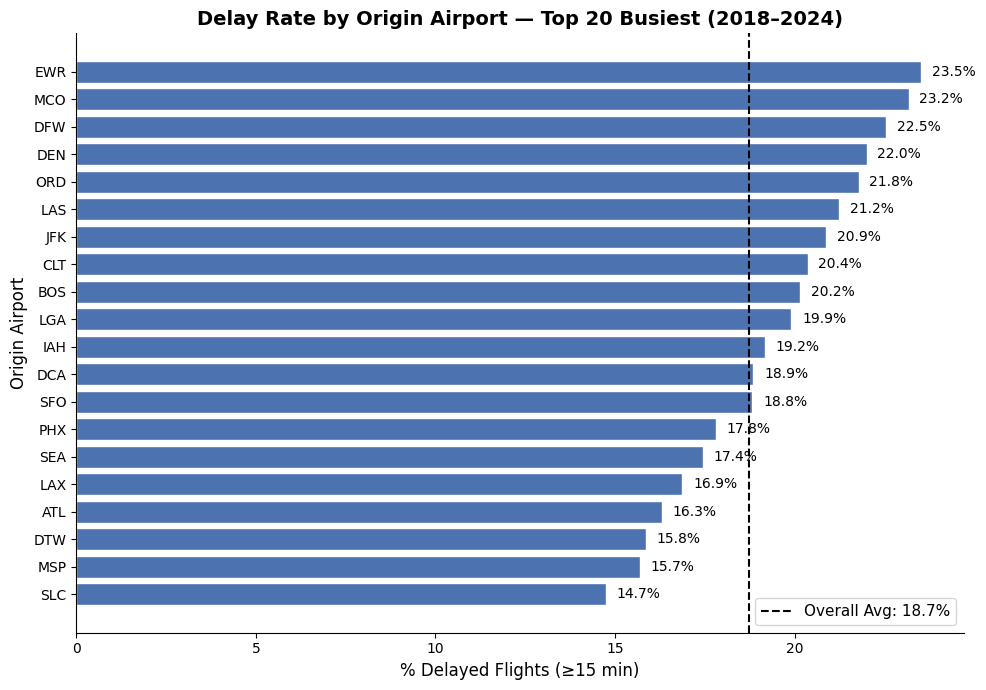

In [10]:
# Get top 20 busiest origin airports by flight volume
top20_origins = df['Origin'].value_counts().head(20).index

origin_delay = (
    df[df['Origin'].isin(top20_origins)]
    .dropna(subset=['ArrDel15'])
    .groupby('Origin', observed=True)['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
    .sort_values('Pct_Delayed', ascending=True)
)

origin_delay['Pct_Delayed'] = origin_delay['Pct_Delayed'].astype(float)

print(origin_delay)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    origin_delay['Origin'].astype(str),
    origin_delay['Pct_Delayed'],
    color='#4c72b0',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Origin Airport — Top 20 Busiest (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylabel('Origin Airport', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_origin.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Delay Rate by Destination Airport (Top 20 by Volume)

In [ ]:
# Get top 20 busiest destination airports by flight volume
top20_dests = df['Dest'].value_counts().head(20).index

dest_delay = (
    df[df['Dest'].isin(top20_dests)]
    .dropna(subset=['ArrDel15'])
    .groupby('Dest', observed=True)['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
    .sort_values('Pct_Delayed', ascending=True)
)

dest_delay['Pct_Delayed'] = dest_delay['Pct_Delayed'].astype(float)

print(dest_delay)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    dest_delay['Dest'].astype(str),
    dest_delay['Pct_Delayed'],
    color='#55a868',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Destination Airport — Top 20 Busiest (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylabel('Destination Airport', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_dest.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 1 — Key Findings: Categorical Feature Analysis

- Delay rates vary significantly across airlines (14.1% to 26.9%) and airports (13.9% to 24.9%), confirming both are strong predictors of delay.
- EWR (Newark) is the worst airport in both origin and destination charts, while NYC-area airports (EWR, LGA, JFK) consistently rank above the overall average — likely driven by airspace congestion.
- With 384 unique airports, one-hot encoding is impractical; target encoding is recommended, while `Reporting_Airline` (19 values) can be safely one-hot encoded.

## Section 2: Temporal Feature Analysis

### 2.1 Delay Rate by Hour of Day

    DepHour  Pct_Delayed
0         0        18.08
1         1        18.65
2         2        23.30
3         3        23.27
4         4        19.73
5         5         8.47
6         6         9.42
7         7        11.51
8         8        12.96
9         9        14.01
10       10        15.11
11       11        15.94
12       12        17.52
13       13        19.10
14       14        20.89
15       15        22.18
16       16        23.72
17       17        24.41
18       18        25.77
19       19        26.26
20       20        26.17
21       21        26.01
22       22        24.12
23       23        20.44
24       24         0.00


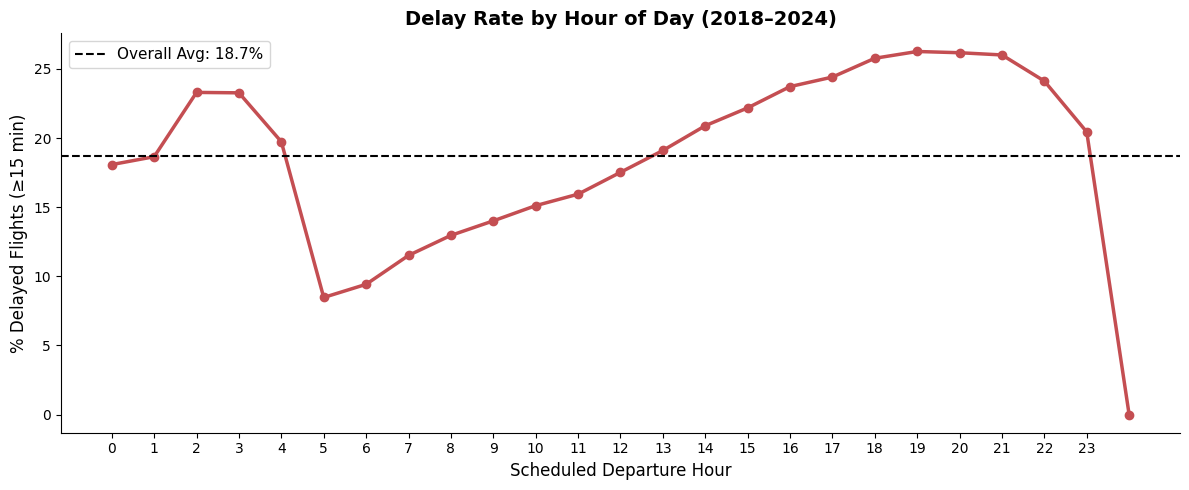

In [12]:
# Derive hour of day from CRSDepTime 
df['DepHour'] = df['CRSDepTime'] // 100

hour_delay = (
    df.dropna(subset=['ArrDel15'])
    .groupby('DepHour')['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
)

hour_delay['Pct_Delayed'] = hour_delay['Pct_Delayed'].astype(float)

print(hour_delay)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    hour_delay['DepHour'],
    hour_delay['Pct_Delayed'],
    color='#c44e52',
    linewidth=2.5,
    marker='o',
    markersize=6
)

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axhline(y=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Hour of Day (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Scheduled Departure Hour', fontsize=12)
ax.set_ylabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Delay Rate by Day of Week

   Day  Pct_Delayed
0  Mon        18.98
1  Tue        16.70
2  Wed        17.25
3  Thu        19.91
4  Fri        20.58
5  Sat        17.66
6  Sun        19.61


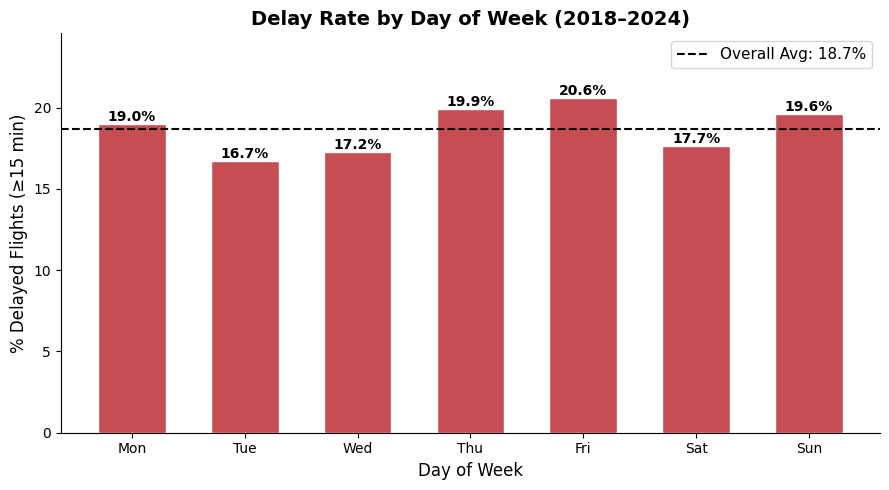

In [13]:
day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}

dow_delay = (
    df.dropna(subset=['ArrDel15'])
    .groupby('DayOfWeek')['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
)

dow_delay['Pct_Delayed'] = dow_delay['Pct_Delayed'].astype(float)
dow_delay['Day'] = dow_delay['DayOfWeek'].map(day_names)

print(dow_delay[['Day', 'Pct_Delayed']])

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    dow_delay['Day'],
    dow_delay['Pct_Delayed'],
    color='#c44e52',
    edgecolor='white',
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f'{height:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axhline(y=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Day of Week (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylim(0, dow_delay['Pct_Delayed'].max() + 4)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_dow.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Delay Rate by Month

   MonthName  Pct_Delayed
0        Jan        18.19
1        Feb        18.13
2        Mar        17.47
3        Apr        17.96
4        May        19.28
5        Jun        23.34
6        Jul        23.59
7        Aug        20.92
8        Sep        15.03
9        Oct        15.31
10       Nov        15.16
11       Dec        19.91


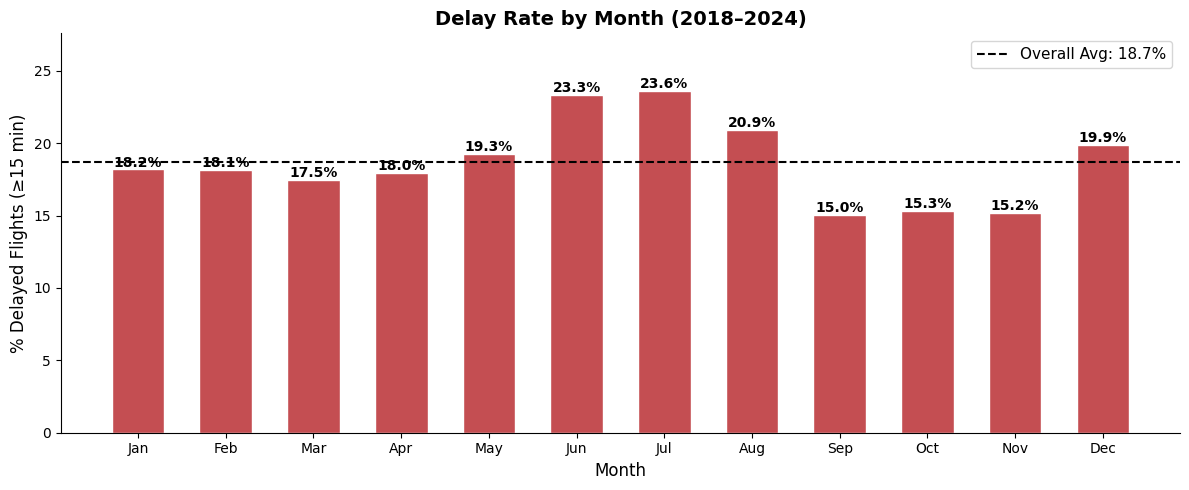

In [14]:
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

month_delay = (
    df.dropna(subset=['ArrDel15'])
    .groupby('Month')['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
)

month_delay['Pct_Delayed'] = month_delay['Pct_Delayed'].astype(float)
month_delay['MonthName'] = month_delay['Month'].map(month_names)

print(month_delay[['MonthName', 'Pct_Delayed']])

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    month_delay['MonthName'],
    month_delay['Pct_Delayed'],
    color='#c44e52',
    edgecolor='white',
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f'{height:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axhline(y=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Month (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylim(0, month_delay['Pct_Delayed'].max() + 4)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 2 — Key Findings: Temporal Feature Analysis

- Delay rate is lowest at 5am (8.6%) and peaks in the evening (26% at 7–9pm). This is showing a clear accumulation effect as delays cascade throughout the day.
- Friday (20.6%) and Sunday (19.6%) are the worst days while Tuesday (16.7%) and Wednesday (17.2%) are the most reliable.
- Summer months (June 23.3%, July 23.6%) and December (19.9%) have the highest delay rates driven by peak travel demand and weather, while fall months (Sep–Nov around 15%) are consistently the best.

## Section 3: Distance & Delay

### 3.1 Delay Rate by Distance Bin

            DistanceBin  Pct_Delayed
0      Short\n(0–500mi)        17.26
1  Medium\n(500–1000mi)        19.03
2   Long\n(1000–1500mi)        20.66
3  Very Long\n(1500mi+)        19.66


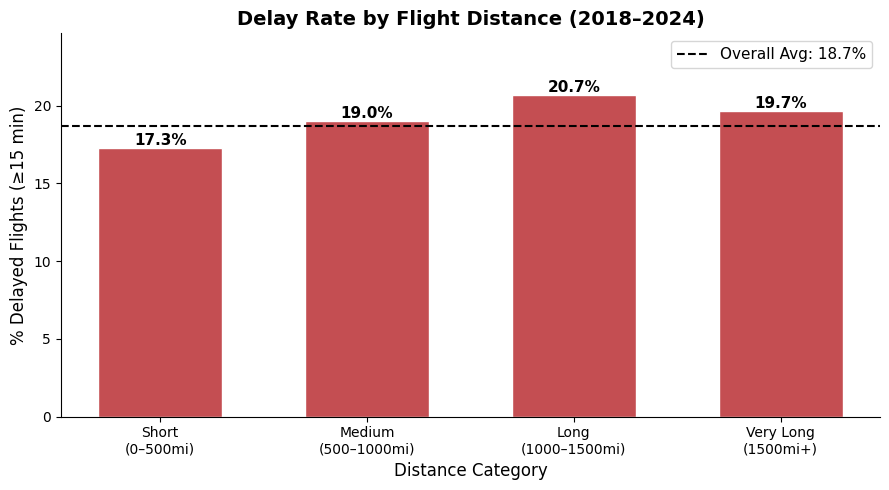

In [15]:
# Bin distance into 4 groups
bins = [0, 500, 1000, 1500, df['Distance'].max()]
labels = ['Short\n(0–500mi)', 'Medium\n(500–1000mi)', 'Long\n(1000–1500mi)', 'Very Long\n(1500mi+)']

df['DistanceBin'] = pd.cut(df['Distance'], bins=bins, labels=labels)

dist_delay = (
    df.dropna(subset=['ArrDel15', 'DistanceBin'])
    .groupby('DistanceBin', observed=True)['ArrDel15']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'ArrDel15': 'Pct_Delayed'})
)

dist_delay['Pct_Delayed'] = dist_delay['Pct_Delayed'].astype(float)

print(dist_delay)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    dist_delay['DistanceBin'].astype(str),
    dist_delay['Pct_Delayed'],
    color='#c44e52',
    edgecolor='white',
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f'{height:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

overall_avg = float(df['ArrDel15'].mean()) * 100
ax.axhline(y=overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall Avg: {overall_avg:.1f}%')

ax.set_title('Delay Rate by Flight Distance (2018–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance Category', fontsize=12)
ax.set_ylabel('% Delayed Flights (≥15 min)', fontsize=12)
ax.set_ylim(0, dist_delay['Pct_Delayed'].max() + 4)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('delay_rate_by_distance.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 3 — Key Findings: Distance & Delay

- Short flights (0–500mi) have the lowest delay rate at 17.3%, while long flights (1000–1500mi) peak at 20.7%.
- Very long flights (1500mi+) go to 19.7%, which suggest that flights have more time to make up delays in the air.

## Section 4: Feature Cardinality & Encoding Implications

### 4.1 Feature Cardinality Table

In [16]:
features = ['Reporting_Airline', 'Origin', 'Dest', 'DepTimeBlk',
            'Month', 'DayOfWeek', 'DayofMonth', 'DistanceGroup']

cardinality = []
for col in features:
    n = df[col].nunique()
    if n <= 20:
        level = 'Low'
    elif n <= 100:
        level = 'Medium'
    else:
        level = 'High'
    cardinality.append({'Feature': col, 'Unique Values': n, 'Cardinality': level})

card_df = pd.DataFrame(cardinality).sort_values('Unique Values', ascending=False)
print(card_df.to_string(index=False))

          Feature  Unique Values Cardinality
           Origin            384        High
             Dest            384        High
       DayofMonth             31      Medium
Reporting_Airline             19         Low
       DepTimeBlk             19         Low
            Month             12         Low
    DistanceGroup             11         Low
        DayOfWeek              7         Low


### 4.2 Cardinality Bar Chart

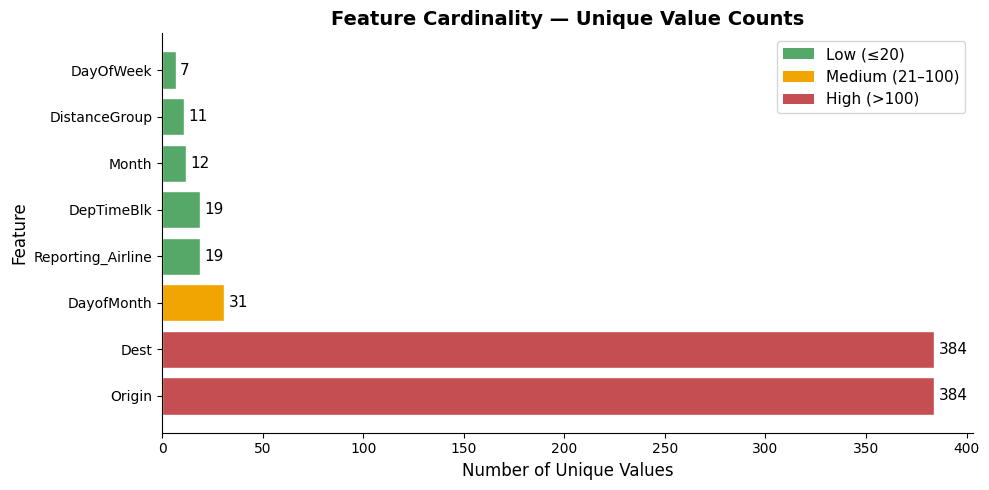

In [17]:
color_map = {'Low': '#55a868', 'Medium': '#f0a500', 'High': '#c44e52'}
colors = [color_map[c] for c in card_df['Cardinality']]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    card_df['Feature'],
    card_df['Unique Values'],
    color=colors,
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va='center',
        fontsize=11
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#55a868', label='Low (≤20)'),
    Patch(facecolor='#f0a500', label='Medium (21–100)'),
    Patch(facecolor='#c44e52', label='High (>100)')
]
ax.legend(handles=legend_elements, fontsize=11)

ax.set_title('Feature Cardinality — Unique Value Counts', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Unique Values', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Encoding Implications

- `Origin` and `Dest` (384 unique values each) are high cardinality — one-hot encoding would create 768 sparse columns, making the model slower and harder to train. We can use target encoding (replacing each airport with its historical delay rate) is the best option.
- `Reporting_Airline` and `DepTimeBlk` (19 unique values each) are low cardinality and safe to one-hot encode.
- Numeric and ordinal features (`Month`, `DayOfWeek`, `DayofMonth`, `DistanceGroup`) can be used as-is — no encoding needed.

## Section 5: Conclusion

This EDA examines teh feature relationships across categorical, temporal, and distance dimensions to understand what drives flight arrival delays and what that means for model selection.

**Following are some of thekKey findings:**

- Airline and airport are the strongest predictors — delay rates range from 14.1% to 26.9% across carriers and 13.9% to 24.9% across airports.
- Time of day shows a strong nonlinear pattern — delay rates are lowest at 5am (8.6%) and peak in the evening (26%).
- Distance has a weaker effect but interacts with airline and airport — long-haul routes tend to connect busy hubs with already-high delay rates.

**Modeling implication:**

Strong nonlinear interactions between time-of-day, carrier, and airport suggest tree-based models (Random Forest, XGBoost) are well-suited for this prediction task. These patterns cannot be adequately captured by logistic regression as it assumes linear relationships between features and the target.